# Single-cell segmented data (Xenium Prime 5K)

This notebook demonstrates how to run SPLISOSM's spatial variability and differential usage tests on single-cell segmented spatial transcriptomics data, using [the 10x Genomics Xenium Prime 5K Mouse Brain Coronal dataset](https://www.10xgenomics.com/datasets/xenium-prime-fresh-frozen-mouse-brain) as an example. Because cell centroids are not on a regular grid, `SplisosmFFT` does not apply; we use `SplisosmNP` instead. The following analyses are performed:

1. Run spatial variability (SV) tests to identify **spatially variably processed (SVP)** genes with variable codeword usage, including on a per-cluster basis (within cell-type variability).
2. Run differential isoform usage (DU) test to find cluster-specific codeword usage switches, as well as SVP usage associations with RBP (RNA-binding protein) expression.
3. Run variability tests using an **expression-based k-NN graph** to identify genes with variable codeword usage across cell states.

Estimated runtime: ~10 min.

## Preliminary notes

For Xenium Prime 5K datasets, each gene is profiled by multiple [codewords (i.e., exon/junction probe sets)](https://www.10xgenomics.com/support/software/xenium-panel-designer/latest/tutorials/xenium-panel-design-concepts-terms#codewords). This notebook uses the same Xenium dataset as presented in the SPLISOSM paper and as in the [SplisosmFFT Xenium Prime 5K tutorial](./xenium_prime_5k.ipynb).

- The dataset can be downloaded from 10x Genomics [here](https://www.10xgenomics.com/datasets/xenium-prime-fresh-frozen-mouse-brain)
- Probe set (5K Mouse Pan Tissue and Pathways Panel) information is available [here](https://www.10xgenomics.com/support/software/xenium-panel-designer/latest/tutorials/pre-designed-xenium-prime-5k). 

Cell-segmentation was performed as part of the Xenium Onboard Analysis. After downloading Xenium analysis outputs, we reran the Xenium Ranger v3.1.0 relabel pipeline to get codeword transcript counts. Due to Xenium output data structure changes, if you encounter issues, consider re-running the Xenium Ranger (**v3.1.0+**) relabel pipeline as well. See [10x documentation](https://www.10xgenomics.com/support/software/xenium-ranger/latest/analysis/running-pipelines/XR-relabel) for guidance.

## Imports

In [1]:
from pathlib import Path
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from splisosm import SplisosmNP
from splisosm.utils import add_ratio_layer
from splisosm.io import load_xenium_codeword

# set random seed for reproducibility
np.random.seed(0)

## Configure paths and core parameters

In [2]:
# Required: Xenium Ranger output directory (either the `outs` dir itself or its parent)
xenium_prime_outs = Path('/path/to/xenium_prime_5k/outs')

# Feature grouping and filters
group_iso_by = 'gene_symbol'
gene_name_col = 'gene_symbol'
min_counts = 50
min_bin_pct = 0.01

# Xenium transcript filter
quality_threshold = 20.0

In [3]:
# local path
xenium_prime_outs = Path('/Users/jysumac/Projects/SPLISOSM_paper/data/xenium_5k_mouse_brain/codeword-relabel/outs')

## Load single-cell segmented data

We use `splisosm.io.load_xenium_codeword` to load the cell-by-gene and cell-by-codeword count matrices from Xenium outputs and relevant metadata as a SpatialData object. 

- `spatial_resolutions=[]` disables spatial binning
- `build_cell_codeword_table=True` loads both the cell-by-codeword and the cell-by-gene AnnData.


In [4]:
%%time
print('Building Xenium codeword SpatialData from transcript chunks...')
sdata = load_xenium_codeword(
    path=xenium_prime_outs,
    spatial_resolutions=[], # or None to skip binning
    quality_threshold=quality_threshold,
    counts_layer_name='counts',
    build_cell_codeword_table=True, # also build cell-by-codeword table
    transcripts=False, # skip transcript-level points
    n_jobs=1
)

sdata

Building Xenium codeword SpatialData from transcript chunks...


/Users/jysumac/miniforge3/envs/splisosm_dev/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


CPU times: user 49.2 s, sys: 16 s, total: 1min 5s
Wall time: 27.1 s


SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 23912, 34154), (4, 11956, 17077), (4, 5978, 8538), (4, 2989, 4269), (4, 1494, 2134)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (23912, 34154), (11956, 17077), (5978, 8538), (2989, 4269), (1494, 2134)
│     └── 'nucleus_labels': DataTree[yx] (23912, 34154), (11956, 17077), (5978, 8538), (2989, 4269), (1494, 2134)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (63173, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (63036, 1) (2D shapes)
└── Tables
      ├── 'table': AnnData (63173, 5006)
      └── 'table_codeword': AnnData (63173, 11163)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

There are two anndata objects associated with this dataset:

- `sdata.tables['table']`: cell-by-gene counts (default loaded by `spatialdata-io`)
- `sdata.tables['table_codeword']`: cell-by-codeword counts. Cell centroid spatial coordinates are stored in `adata.obsm['spatial']`.

In [5]:
adata_gene = sdata.tables['table']
adata_codeword = sdata.tables['table_codeword']
print(f"=== Number of cells: {adata_codeword.shape[0]} ===")
print(f"=== Number of genes: {adata_gene.shape[1]} ===")
print(f"=== Number of codewords: {adata_codeword.shape[1]} ===")

=== Number of cells: 63173 ===
=== Number of genes: 5006 ===
=== Number of codewords: 11163 ===


### Expression-based clustering

We first run the standard Scanpy preprocessing and clustering pipeline to get gene-expression-based cell clusters. Similar to differentially expressed gene markers, we can also identify genes with differential codeword usage across clusters using Splisosm's DU test (to be described later).

In [6]:
%%time
# set obs_name to cell_id
adata_gene.obs.set_index('cell_id', inplace=True)

# log-normalization
adata_gene.layers['counts'] = adata_gene.X.copy()
sc.pp.normalize_total(adata_gene, target_sum=1e4)
sc.pp.log1p(adata_gene)
adata_gene.layers['log1p'] = adata_gene.X.copy()

# dimensionality reduction
sc.pp.highly_variable_genes(adata_gene, n_top_genes=2000, layer='log1p')
sc.pp.pca(adata_gene, n_comps=50, use_highly_variable=True, layer='log1p')

<timed exec>:6: UserWarning: Some cells have zero counts


CPU times: user 4.34 s, sys: 241 ms, total: 4.58 s
Wall time: 4.51 s


In [7]:
%%time
# neighborhood graph and UMAP
sc.pp.neighbors(adata_gene, n_neighbors=15)
sc.tl.umap(adata_gene)

# clustering
sc.tl.leiden(adata_gene, flavor="igraph", n_iterations=2, resolution=0.5)

CPU times: user 34.4 s, sys: 593 ms, total: 35 s
Wall time: 35.5 s


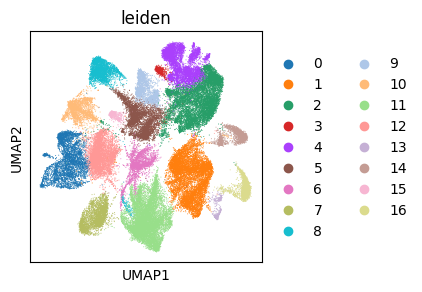

In [8]:
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.umap(adata_gene, color=["leiden"])

In addition to the cell annotation, we also get an expression-based symmetric k-NN graph, which can be used to build a "spatial" kernel to detect variability patterns across the population without discretizing the latent space (in the final section).

In [9]:
print(f"Average row-connectivity: {adata_gene.obsp['connectivities'].getnnz(axis=1).mean() :.2f}")
print(f"Average column-connectivity: {adata_gene.obsp['connectivities'].getnnz(axis=0).mean() :.2f}")
print(f"Is symmetric: {adata_gene.obsp['connectivities'].nnz == adata_gene.obsp['connectivities'].T.nnz}")
print(f"Self-loops: {adata_gene.obsp['connectivities'].diagonal().sum()}")

Average row-connectivity: 22.52
Average column-connectivity: 22.52
Is symmetric: True
Self-loops: 0.0


### Codeword anndata preprocessing

In [10]:
%%time
# Copy relevant metadata to codeword anndata
adata_codeword.obs['leiden'] = adata_gene.obs['leiden'].copy()
adata_codeword.obsm['X_umap_expr'] = adata_gene.obsm['X_umap'].copy()
adata_codeword.obsp['expr_knn'] = adata_gene.obsp['connectivities'].copy()

# Compute codeword usage ratios per gene for visualization
add_ratio_layer(
    adata_codeword, layer="counts", group_iso_by=group_iso_by,
    ratio_layer_key="ratios_obs", fill_nan_with_mean=False
)

# Cache log1p counts for visualization
adata_codeword.layers['log1p'] = np.log1p(adata_codeword.layers['counts'])

CPU times: user 3.26 s, sys: 470 ms, total: 3.73 s
Wall time: 3.79 s


## Spatial variability (SV) testing

When computing the **HSIC-IR** statistic to identify **spatially variably processed (SVP)** genes with varying codeword usage ratios, `SplisosmNP` first builds a sparse CAR spatial kernel from a k-mutual-nearest neighbors graph of cell centroids. The following hyperparameters control the spatial kernel construction:

- `k_neighbors`: Number of neighbors for building the k-NN graph. 
- `rho`: Spatial autocorrelation parameter for the CAR kernel, between 0 and 1.

In general, **larger `k` and `rho` prioritize global, low-frequency spatial patterns**, while smaller `k` and `rho` prioritize local, high-frequency patterns. See the [Hyperparameter sensitivity check section in the SplisosmFFT notebook](./visiumhd_ffpe.ipynb) for their effect on kernel spectrum and downstream SV test results.

In [11]:
%%time
# Model setup
model_sv = SplisosmNP(
    k_neighbors=4,
    rho=0.99,
    standardize_cov=True # will slow down .setup_data
)

CPU times: user 5 μs, sys: 5 μs, total: 10 μs
Wall time: 11.9 μs


While the k-NN graph is flexible in handling complex spatial structures, it is **sensitive to spatial outliers**, such as tiny disconnected tissue fragments that form small connected components. Without proper filtering, signals from these isolated components can dominate the test statistic, leading to non-biological SV calls. To mitigate this, the following defaults are recommended:

- `standardize_cov=True`: Scales the spatial kernel's diagonal to 1 during construction so all spots have equal influence.
- `min_component_size`: Filters out spots in small, disconnected fragments during `setup_data` (e.g., `min_component_size=10` removes graph components smaller than 10 spots).

You can also apply feature-level filters to exclude rarely expressed genes and codewords:

- `min_counts`: Minimum total counts across all spots required to retain a codeword.
- `min_bin_pct`: Minimum percentage of spots with non-zero counts required to retain a codeword.
- `filter_single_iso_genes`: Removes genes with only one codeword. Such genes cannot exhibit isoform switching (irrelevant for `'hsic-ir'`) but may still have expression variability (relevant for `'hsic-gc'` and `'hsic-ic'`).

In [12]:

%%time
model_sv.setup_data(
    adata=adata_codeword,
    spatial_key="spatial",
    layer="counts",
    group_iso_by=group_iso_by,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    filter_single_iso_genes=True,
    min_component_size=4, # remove disconnected tissue fragments with very few cells
)
model_sv

/Users/jysumac/Projects/SPLISOSM/src/splisosm/utils/preprocessing.py:832: UserWarning: Removed 893 spot(s) belonging to graph components with fewer than 4 member(s). 62280 spot(s) remain.
  spatial_inputs = _filter_small_components(


CPU times: user 41 s, sys: 12.4 s, total: 53.4 s
Wall time: 41.2 s


=== SplisosmNP
- Number of genes: 3058
- Number of spots: 62280
- Number of covariates: 0
- Average isoforms per gene: 2.1
=== Model configurations
- Spatial kernel source: spatial_key='spatial' (component-filtered)
- k_neighbors: 4, rho: 0.99
- Standardize spatial covariance: True
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

To compute p-values for the HSIC-IR test statistic, we use Liu's four-moment matching method (`null_method="liu"`), with cumulants estimated via Hutchinson-Rademacher probes (`null_configs={"n_probes": m}`).

- For larger datasets, reducing `n_probes` speeds up computation but may reduce trace accuracy.
- For a faster alternative, the Welch-Satterthwaite two-moment matching method (`null_method="welch"`) is roughly twice as fast as the Liu method.

See [Methods documentation](../methods.rst) for more details on null distribution approximations.

In [13]:
%%time
model_sv.test_spatial_variability(
    method="hsic-ir",
    null_method="liu",
    null_configs={"n_probes": 60},
    ratio_transformation="none",
    nan_filling="mean",
    print_progress=True,
)
sv_liu = model_sv.get_formatted_test_results("sv", with_gene_summary=True)

SV [hsic-ir]: 100%|██████████| 203/203 [00:03<00:00, 60.56it/s]


CPU times: user 16.4 s, sys: 3.58 s, total: 20 s
Wall time: 6.06 s


In [14]:
sv_liu_sig = sv_liu[sv_liu["pvalue_adj"] < 0.01]
print(f"SVP genes (Liu, FDR < 1%): {len(sv_liu_sig)} / {sv_liu.shape[0]}")
sv_liu.sort_values("pvalue_adj").head(5)

SVP genes (Liu, FDR < 1%): 782 / 3058


,gene,statistic,pvalue,pvalue_adj,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
2521,Ckb,0.000005,0.000000e+00,0.000000e+00,2,1.918832,0.932193,7.287765,6.599467,0.642925
934,Ryr1,0.000001,0.000000e+00,0.000000e+00,2,1.988887,0.052762,0.073988,0.372399,0.552734
1805,Syne1,0.000005,1.904233e-309,1.941048e-306,2,1.991829,0.489804,1.001477,1.448173,0.545213
1906,Cxcl12,0.000002,4.799691e-263,3.669364e-260,2,1.995067,0.165125,0.327746,1.082900,0.535126
2726,Saraf,0.000005,3.476112e-213,2.125990e-210,2,1.951907,0.595151,1.156214,1.378051,0.609868


### Emphasizing broad smooth patterns

Prior releases used a low-rank SV path by default for data with `n > 5000`. The default is now the full-rank Liu cumulant test. If broad smooth patterns are the main target, increase `rho` (for example, `rho=0.999`) rather than truncating the spatial rank. The next cells rerun the SV test with a smoother CAR kernel. See the [SV hyperparameter optimization notebook](visiumhd_ffpe_svhp.ipynb) for comparison with the legacy low-rank approach.

In [15]:
%%time
model_sv_global = SplisosmNP(
    k_neighbors=4,
    rho=0.999, # between 0 and 1, higher values prioritize global patterns more
    standardize_cov=True # will slow down .setup_data
)
model_sv_global.setup_data(
    adata=adata_codeword,
    spatial_key="spatial",
    layer="counts",
    group_iso_by=group_iso_by,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    filter_single_iso_genes=True,
    min_component_size=4, # remove disconnected tissue fragments with very few cells
)

/Users/jysumac/Projects/SPLISOSM/src/splisosm/utils/preprocessing.py:832: UserWarning: Removed 893 spot(s) belonging to graph components with fewer than 4 member(s). 62280 spot(s) remain.
  spatial_inputs = _filter_small_components(


CPU times: user 41.3 s, sys: 13.2 s, total: 54.5 s
Wall time: 42.2 s


In [16]:
%%time
model_sv_global.test_spatial_variability(
    method="hsic-ir",
    null_method="liu",
    null_configs={"n_probes": 60},
    ratio_transformation="none",
    nan_filling="mean",
    print_progress=True,
)
sv_liu_gl = model_sv_global.get_formatted_test_results("sv", with_gene_summary=True)
sv_liu_gl_sig = sv_liu_gl[sv_liu_gl["pvalue_adj"] < 0.01]
print(f"SVP genes (Liu, FDR < 1%): {len(sv_liu_gl_sig)} / {sv_liu_gl.shape[0]}")

SV [hsic-ir]: 100%|██████████| 203/203 [00:03<00:00, 60.41it/s]


SVP genes (Liu, FDR < 1%): 1330 / 3058
CPU times: user 16.4 s, sys: 3.64 s, total: 20.1 s
Wall time: 5.96 s


### Visualize top SVP genes

=== Plotting gene: Ryr1 ===


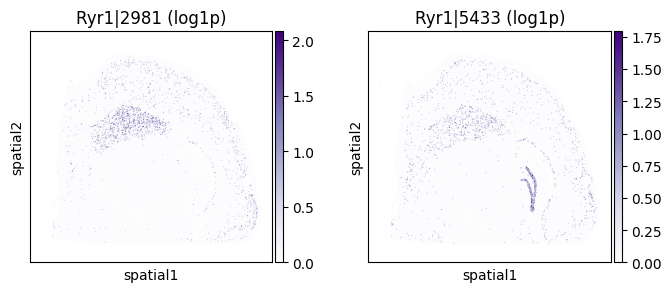

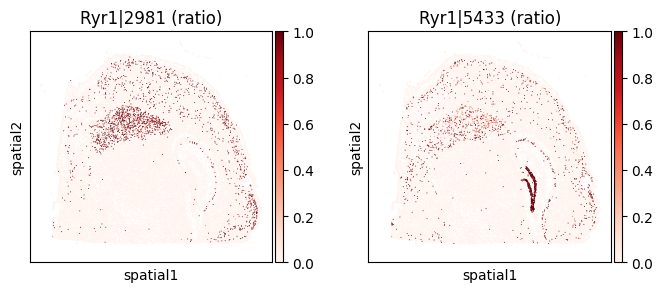

=== Plotting gene: Ckb ===


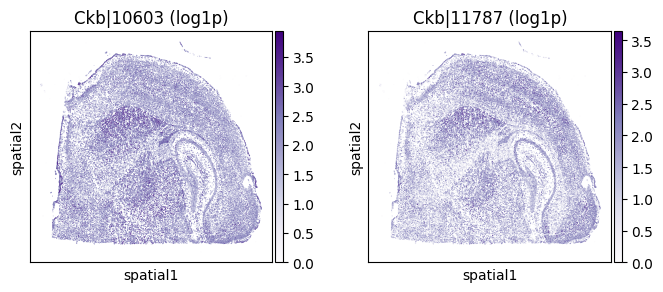

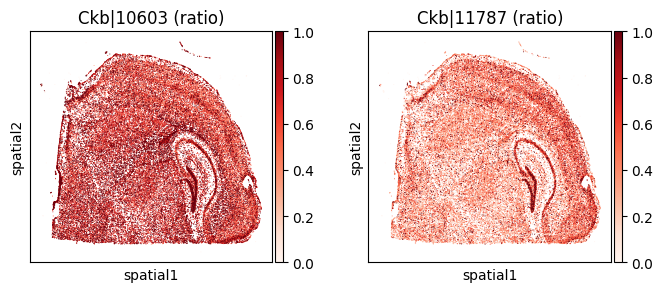

=== Plotting gene: Syne1 ===


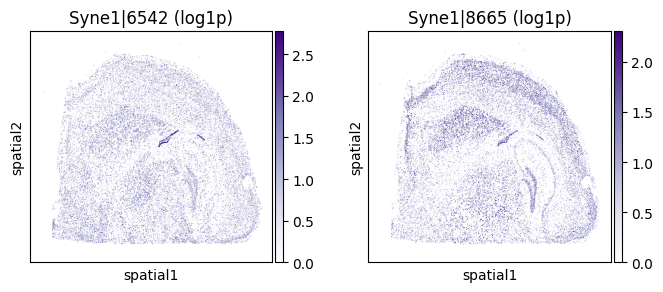

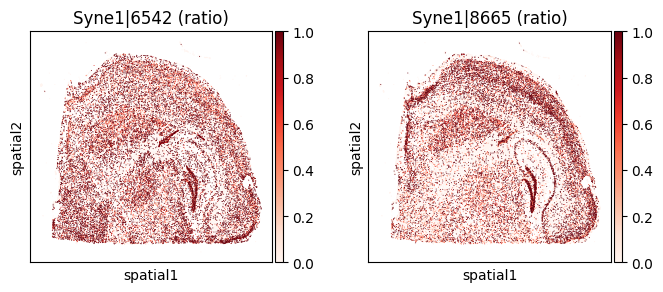

In [17]:
top_genes = sv_liu.sort_values('pvalue').head(5)['gene'].tolist()
for _gene in top_genes[:3]:
    print(f"=== Plotting gene: {_gene} ===")
    _cw_to_plot = adata_codeword.var.query("gene_symbol == @_gene").index.tolist()
    _titles_log1p = [f"{_cw} (log1p)" for _cw in _cw_to_plot]
    _titles_ratio = [f"{_cw} (ratio)" for _cw in _cw_to_plot]
    with plt.rc_context({"figure.figsize": (3, 3)}):
        sc.pl.embedding(
            adata_codeword, basis='spatial', 
            color=_cw_to_plot, title=_titles_log1p,
            layer="log1p", cmap="Purples", vmin=0.0
        )
        sc.pl.embedding(
            adata_codeword, basis='spatial', 
            color=_cw_to_plot, title=_titles_ratio,
            layer="ratios_obs", cmap="Reds", vmin=0.0
        )

### Within-cluster SVP genes

By subsetting to a single expression-based cluster, we can similarly identify spatially variable codeword usage within that cluster. Here we pick Cluster 2 (cortical neurons) as an example.

In [18]:
%%time
# Subset to cluster 2
adata_sub = adata_codeword[adata_codeword.obs['leiden'] == '2']

model_sv_sub = SplisosmNP(
    k_neighbors=4,
    rho=0.99,
    standardize_cov=True # will slow down .setup_data
)
model_sv_sub.setup_data(
    adata=adata_sub,
    spatial_key="spatial",
    layer="counts",
    group_iso_by=group_iso_by,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    filter_single_iso_genes=True,
    min_component_size=4, # remove disconnected tissue fragments with very few cells
)
model_sv_sub

/Users/jysumac/Projects/SPLISOSM/src/splisosm/utils/preprocessing.py:832: UserWarning: Removed 312 spot(s) belonging to graph components with fewer than 4 member(s). 9021 spot(s) remain.
  spatial_inputs = _filter_small_components(


CPU times: user 1.12 s, sys: 358 ms, total: 1.48 s
Wall time: 1.22 s


=== SplisosmNP
- Number of genes: 2657
- Number of spots: 9021
- Number of covariates: 0
- Average isoforms per gene: 2.1
=== Model configurations
- Spatial kernel source: spatial_key='spatial' (component-filtered)
- k_neighbors: 4, rho: 0.99
- Standardize spatial covariance: True
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

In [19]:
%%time
model_sv_sub.test_spatial_variability(
    method="hsic-ir",
    null_method="liu",
    ratio_transformation="none",
    nan_filling="mean",
    print_progress=True,
)
sv_sub = model_sv_sub.get_formatted_test_results("sv", with_gene_summary=True)
sv_sub.sort_values("pvalue_adj").head(5)

SV [hsic-ir]: 100%|██████████| 177/177 [00:01<00:00, 120.28it/s]


CPU times: user 3.28 s, sys: 1.36 s, total: 4.63 s
Wall time: 2.53 s


,gene,statistic,pvalue,pvalue_adj,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
206,Arhgef15,0.000006,5.768157e-82,1.532599e-78,2,1.757146,0.077486,0.089569,0.334875,0.748762
2200,Ckb,0.000029,7.770494e-77,1.032310e-73,2,1.988247,0.941692,7.050770,5.190899,0.554233
1416,Rtn3,0.000023,1.964297e-45,1.739712e-42,2,1.915458,0.936149,6.920075,5.431430,0.645885
1565,Syne1,0.000036,1.338255e-40,8.889357e-38,2,1.872818,0.621993,1.305288,1.467576,0.679236
1863,Sncb,0.000012,1.599602e-30,8.500287e-28,2,1.822768,0.963086,13.934819,10.792033,0.711995


=== Plotting gene: Arhgef15 ===


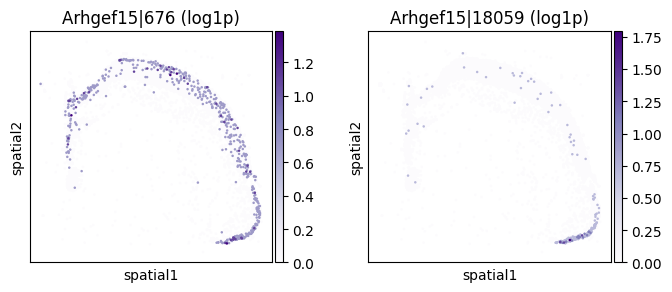

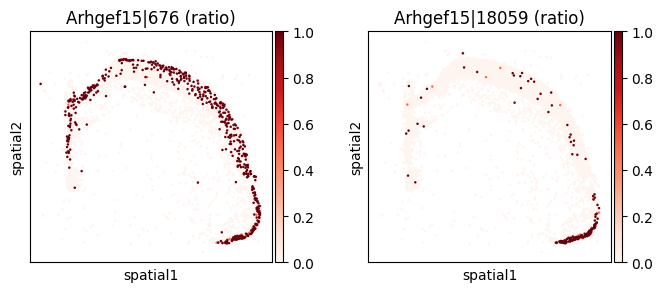

In [20]:
_gene = sv_sub.sort_values("pvalue_adj").iloc[0]["gene"]
print(f"=== Plotting gene: {_gene} ===")
_cw_to_plot = adata_codeword.var.query("gene_symbol == @_gene").index.tolist()
_titles_log1p = [f"{_cw} (log1p)" for _cw in _cw_to_plot]
_titles_ratio = [f"{_cw} (ratio)" for _cw in _cw_to_plot]
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.embedding(
        adata_sub, basis='spatial', 
        color=_cw_to_plot, title=_titles_log1p,
        layer="log1p", cmap="Purples", vmin=0.0
    )
    sc.pl.embedding(
        adata_sub, basis='spatial', 
        color=_cw_to_plot, title=_titles_ratio,
        layer="ratios_obs", cmap="Reds", vmin=0.0
    )

## Differential codeword usage (DU) testing

Let's focus our analysis on the set of significant SVP genes with spatially variable codeword usage.

In [21]:
# Keep only SVP genes for downstream DU testing
svp_gene_list = sv_liu.query("pvalue_adj < 0.01")["gene"].tolist()
svp_mask = adata_codeword.var["gene_symbol"].isin(svp_gene_list)
adata_svp = adata_codeword[:, svp_mask].copy()

print(f"Keeping {adata_svp.n_vars} codewords from {len(svp_gene_list)} SVP genes (FDR < 1% by Liu test)")

Keeping 1697 codewords from 782 SVP genes (FDR < 1% by Liu test)


### Find cluster-specific SVP genes

Using the gene-expression-defined `leiden` clusters, we can run the differential usage test to find cluster-specific codeword usage patterns. Later, we will show how to run a similar analysis without cluster annotation.

In [22]:
%%time
# Model setup
model_clu = SplisosmNP()
model_clu.setup_data(
    adata=adata_svp,
    spatial_key="spatial",
    layer="counts",
    design_mtx="leiden", # one-hot encode leiden clusters as covariates
    group_iso_by=group_iso_by,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    filter_single_iso_genes=True,
    min_component_size=4, # remove disconnected tissue fragments with very few cells
    skip_spatial_kernel=True # DU test does not require spatial kernel, so we can skip to save time
)
model_clu

/Users/jysumac/Projects/SPLISOSM/src/splisosm/utils/preprocessing.py:832: UserWarning: Removed 893 spot(s) belonging to graph components with fewer than 4 member(s). 62280 spot(s) remain.
  spatial_inputs = _filter_small_components(


CPU times: user 426 ms, sys: 203 ms, total: 629 ms
Wall time: 734 ms


=== SplisosmNP
- Number of genes: 782
- Number of spots: 62280
- Number of covariates: 17
- Average isoforms per gene: 2.2
=== Model configurations
- Spatial kernel source: identity (skip_spatial_kernel=True)
- k_neighbors: N/A, rho: 0.99
- Standardize spatial covariance: True
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

#### Conditional differential usage test

By default, `method="hsic-gp"` will remove potential spatial confounding through Gaussian process regression (GPR), reducing false positives (spurious cluster association driven by chance). Here we use the NUFFT-based implementation (requiring the [`finufft`](https://github.com/flatironinstitute/finufft) package) for its scalability.

In [23]:
%%time
# Conditional test
model_clu.test_differential_usage(
    method="hsic-gp",
    residualize='cov_only', # run GPR only for cluster one-hot
    # run with NUFFT backend for better scalability
    # increase lml_approx_rank for better accuracy at the cost of speed
    gpr_backend="nufft",
    gpr_configs={"covariate": {"lml_approx_rank": 32}},
    # # The default sklearn backend uses subsampling for GP fitting
    # # increase n_inducing for better accuracy at the cost of speed
    # gpr_backend="sklearn",
    # gpr_configs={"covariate": {"n_inducing": 2000}},
    ratio_transformation="none",
    nan_filling="mean",
    print_progress=True,
)
clu_res_gp = model_clu.get_formatted_test_results("du")
clu_res_gp = clu_res_gp.rename(columns={
    "statistic": "stat_gp",
    "pvalue": "pvalue_gp"
})

DU [hsic-gp]: 100%|██████████| 782/782 [00:09<00:00, 85.08it/s]


CPU times: user 46.4 s, sys: 27.5 s, total: 1min 13s
Wall time: 41 s


In [24]:
# Top 1 marker per cluster
clu_res_gp.groupby("covariate").apply(
    lambda df: df.nsmallest(1, "pvalue_gp"),
    include_groups=False
)

,,gene,stat_gp,pvalue_gp,pvalue_adj
covariate,,,,,
leiden_0,544,Ccn2,0.000050,0.000000e+00,0.000000e+00
leiden_1,86,Sptbn2,0.000648,0.000000e+00,0.000000e+00
leiden_10,129,Arrb2,0.000219,0.000000e+00,0.000000e+00
leiden_11,368,Epb41l3,0.000651,0.000000e+00,0.000000e+00
leiden_12,726,Slc2a1,0.000421,0.000000e+00,0.000000e+00
leiden_13,4739,Crb2,0.000025,2.837069e-41,2.218588e-38
leiden_14,99,Sptbn2,0.000417,0.000000e+00,0.000000e+00
leiden_15,11405,Isl1,0.000033,0.000000e+00,0.000000e+00
leiden_16,3875,Ryr1,0.000128,0.000000e+00,0.000000e+00


Most SVP genes have at least one significant cluster association, suggesting that cell type distribution is a major driver of spatial patterns of isoform usage. Importantly, codeword usage and cluster identity are **not one-to-one**. An alternative hierarchical cell type/state annotation may be required to explain more nuanced spatial patterns.

In [25]:
_du_clu_sig = clu_res_gp.query('pvalue_adj < 0.05')
print(f"Cluster-specific DU genes (FDR < 5%): {len(_du_clu_sig['gene'].unique())} / {clu_res_gp['gene'].nunique()}")
print(f"Mean cluster associations per SVP gene: {_du_clu_sig.groupby('gene')['covariate'].nunique().mean():.2f}")

Cluster-specific DU genes (FDR < 5%): 772 / 782
Mean cluster associations per SVP gene: 8.06


#### Visualize top cluster-specific codeword usage events

We can visualize top cluster-specific SVP genes on the UMAP computed from gene expression.

Cluster-specific codeword usage for clu=leiden_0, gene=Ccn2


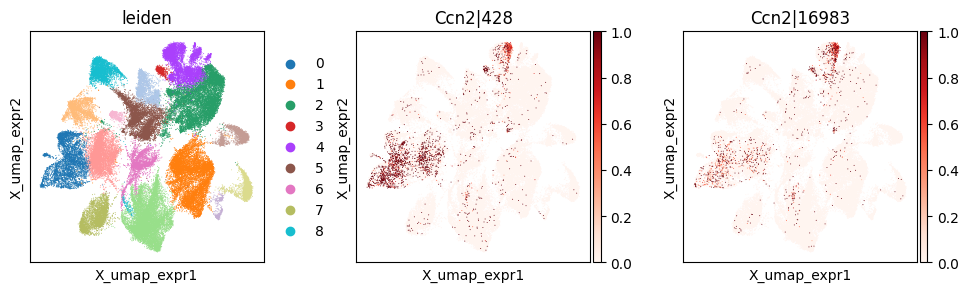

In [26]:
_clu = 'leiden_0'
_gene = clu_res_gp.query('covariate == @_clu').sort_values('pvalue_gp').iloc[0]['gene']
_cw_to_plot = adata_svp.var_names[adata_svp.var["gene_symbol"] == _gene].tolist()
print(f"Cluster-specific codeword usage for clu={_clu}, gene={_gene}")
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.embedding(
        adata_svp, basis='X_umap_expr', 
        color=["leiden"] + _cw_to_plot, layer="ratios_obs", 
        cmap="Reds", vmin=0.0
    )

And also in the physical space.

Cluster-specific codeword usage for clu=leiden_0, gene=Ccn2


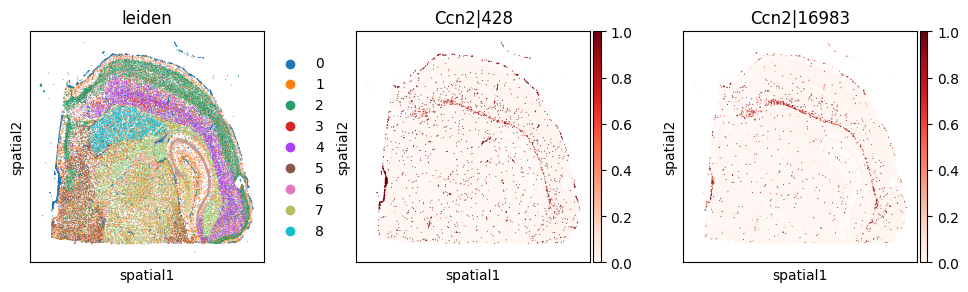

In [27]:
_clu = 'leiden_0'
_gene = clu_res_gp.query('covariate == @_clu').sort_values('pvalue_gp').iloc[0]['gene']
_cw_to_plot = adata_svp.var_names[adata_svp.var["gene_symbol"] == _gene].tolist()
print(f"Cluster-specific codeword usage for clu={_clu}, gene={_gene}")
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.embedding(
        adata_svp, basis='spatial', 
        color=["leiden"] + _cw_to_plot, layer="ratios_obs", 
        cmap="Reds", vmin=0.0
    )

#### Comparison with unconditional differential usage tests

We can also run unconditional tests, including the conventional two-sample T-test (`method="t-fisher"`) and the unconditional HSIC test (`method="hsic"`). These tests are faster but may generate false positives due to spatial confounding.

In [28]:
%%time
# HSIC (multivariate RV coefficient)
model_clu.test_differential_usage(
    method="hsic",
    ratio_transformation="none",
    nan_filling="mean",
    print_progress=True,
)
clu_res_hsic = model_clu.get_formatted_test_results("du")
clu_res_hsic = clu_res_hsic.rename(columns={
    "statistic": "stat_hsic",
    "pvalue": "pvalue_hsic"
})

DU [hsic]: 100%|██████████| 782/782 [00:09<00:00, 84.82it/s]


CPU times: user 15.2 s, sys: 27.3 s, total: 42.6 s
Wall time: 9.42 s


In [29]:
%%time
# T-test (per-isoform pvalues combined by Fishers method)
model_clu.test_differential_usage(
    method="t-fisher",
    ratio_transformation="none",
    nan_filling="mean",
    print_progress=True,
)
clu_res_t = model_clu.get_formatted_test_results("du")
clu_res_t = clu_res_t.rename(columns={
    "statistic": "stat_t",
    "pvalue": "pvalue_t"
})

DU [t-fisher]: 100%|██████████| 782/782 [00:13<00:00, 57.63it/s]


CPU times: user 1min 19s, sys: 9.27 s, total: 1min 28s
Wall time: 13.9 s


In [30]:
def _neg_log10(p, floor=1e-300):
    return -np.log10(np.clip(p, floor, 1.0))

merge_cols = ["gene", "covariate"]

clu_all = (
    clu_res_gp[merge_cols + ["pvalue_gp"]]
    .merge(clu_res_hsic[merge_cols + ["pvalue_hsic"]], on=merge_cols, how="inner")
    .merge(clu_res_t[merge_cols + ["pvalue_t"]], on=merge_cols, how="inner")
)

# Spearman correlations between DU methods
rho_gp_hsic, _  = spearmanr(clu_all["pvalue_gp"],    clu_all["pvalue_hsic"])
rho_gp_t, _ = spearmanr(clu_all["pvalue_gp"],    clu_all["pvalue_t"])
rho_hsic_t, _  = spearmanr(clu_all["pvalue_hsic"],    clu_all["pvalue_t"])

print(f"Spearman ρ(HSIC-GP vs HSIC) = {rho_gp_hsic:.3f}")
print(f"Spearman ρ(HSIC-GP vs T-Fisher) = {rho_gp_t:.3f}")
print(f"Spearman ρ(HSIC vs T-Fisher) = {rho_hsic_t:.3f}")

Spearman ρ(HSIC-GP vs HSIC) = 0.860
Spearman ρ(HSIC-GP vs T-Fisher) = 0.859
Spearman ρ(HSIC vs T-Fisher) = 0.998


The results between HSIC and T-test are highly similar (the test statistics are indeed equivalent, and the difference in p-values is mainly due to different choice of null distribution).
On the other hand, the conditional HSIC-GP test is more conservative and yields shrinking p-values, as expected.

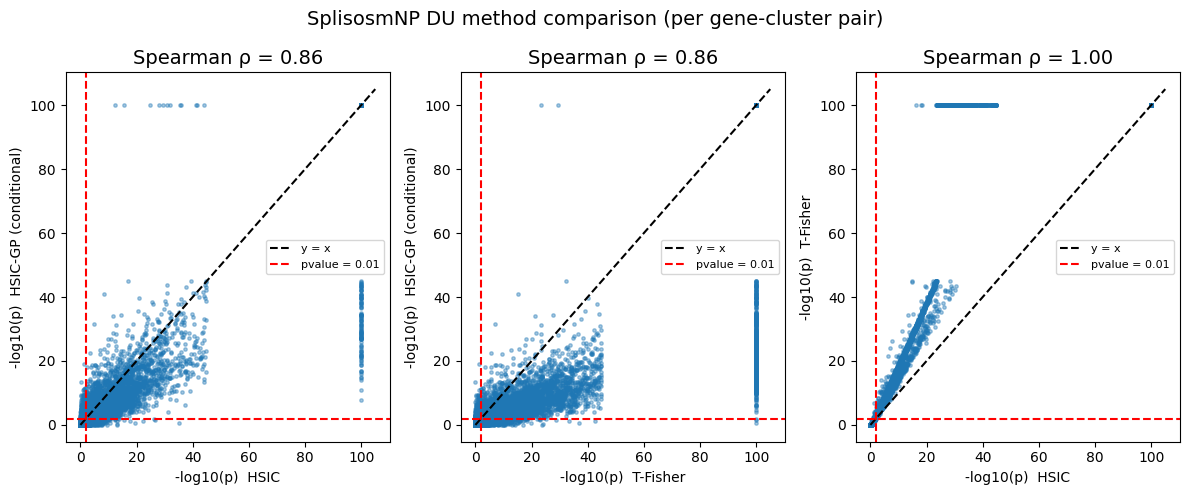

In [31]:
pairs_clu = [
    ("pvalue_hsic",    "pvalue_gp",
     "HSIC", "HSIC-GP (conditional)",  rho_gp_hsic),
    ("pvalue_t",       "pvalue_gp",
     "T-Fisher", "HSIC-GP (conditional)",  rho_gp_t),
    ("pvalue_hsic",    "pvalue_t",
     "HSIC", "T-Fisher",  rho_hsic_t),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for ax, (cx, cy, lx, ly, rho) in zip(axes, pairs_clu):
    x = _neg_log10(clu_all[cx].astype(float).values, floor=1e-100)
    y = _neg_log10(clu_all[cy].astype(float).values, floor=1e-100)
    ax.scatter(x, y, s=6, alpha=0.4, rasterized=True)
    lim = max(x.max(), y.max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", label="y = x")
    ax.axhline(_neg_log10(0.01), color="red", linestyle="--", label="pvalue = 0.01")
    ax.axvline(_neg_log10(0.01), color="red", linestyle="--")
    ax.set_xlabel(f"-log10(p)  {lx}", fontsize=10)
    ax.set_ylabel(f"-log10(p)  {ly}", fontsize=10)
    ax.set_title(f"Spearman ρ = {rho:.2f}", fontsize=14)
    ax.legend(fontsize=8)

fig.suptitle("SplisosmNP DU method comparison (per gene-cluster pair)", fontsize=14)
fig.tight_layout()
plt.show()

### Find potential RBP regulators of SVP genes
Next, we can test for associations between codeword usage of SVP genes and RBP expression to find potential regulators of the observed patterns.

In [32]:
# Build RBP covariate matrix
# A subset of splicing-regulatory RBPs; adapt to the genes in your panel.
rbp_genes = {
    'Ago2', 'Celf', 'Celf1', 'Celf2', 'Celf3', 'Celf4', 'Celf5', 'Celf6', 
    'Elavl1', 'Elavl2', 'Elavl3', 'Elavl4', 'Fus', 
    'Mbnl1', 'Mbnl2', 'Mbnl3', 'Msi1', 'Msi2', 'Nova1', 'Nova2', 
    'Pabpc1', 'Pabpc1l', 'Pabpc2', 'Pabpc4', 'Pabpc5', 'Pabpc6', 'Pabpn1', 
    'Pcbp1', 'Pcbp2', 'Pcbp3', 'Pcbp4', 'Ptbp1', 'Ptbp2', 
    'Qk', 'Rbfox1', 'Rbfox2', 'Rbfox3', 
    'Srsf1', 'Srsf10', 'Srsf12', 'Srsf2', 'Srsf3', 'Srsf4',
    'Srsf5', 'Srsf6', 'Srsf7', 'Srsf9',
}

# Find overlapping genes
rbp_used = [
    rbp for rbp in rbp_genes 
    if rbp in adata_gene.var_names]
print(f"RBP genes in panel: {len(rbp_used)} / {len(rbp_genes)}")
if len(rbp_used) == 0:
    raise RuntimeError(
        "No RBP genes found in the panel. "
        "Check gene name format or extend the rbp_genes list."
    )

# Compute RBP covariate matrix
design_mtx = adata_gene[:, rbp_used].layers["log1p"].copy()
covariate_names = rbp_used
print(f"Design matrix: {design_mtx.shape}  ({len(rbp_used)} RBP covariates)")

RBP genes in panel: 17 / 47
Design matrix: (63173, 17)  (17 RBP covariates)


In [33]:
%%time
# Model setup for DU testing
model_rbp = SplisosmNP()
model_rbp.setup_data(
    adata=adata_svp,
    spatial_key="spatial",
    layer="counts",
    design_mtx=design_mtx,
    covariate_names=covariate_names,
    group_iso_by=group_iso_by,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    filter_single_iso_genes=True,
    min_component_size=4, # remove disconnected tissue fragments with very few cells
    skip_spatial_kernel=True # DU test does not require spatial kernel, so we can skip to save time
)
model_rbp

/Users/jysumac/Projects/SPLISOSM/src/splisosm/utils/preprocessing.py:832: UserWarning: Removed 893 spot(s) belonging to graph components with fewer than 4 member(s). 62280 spot(s) remain.
  spatial_inputs = _filter_small_components(


CPU times: user 478 ms, sys: 278 ms, total: 755 ms
Wall time: 854 ms


=== SplisosmNP
- Number of genes: 782
- Number of spots: 62280
- Number of covariates: 17
- Average isoforms per gene: 2.2
=== Model configurations
- Spatial kernel source: identity (skip_spatial_kernel=True)
- k_neighbors: N/A, rho: 0.99
- Standardize spatial covariance: True
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

In [34]:
%%time
model_rbp.test_differential_usage(
    method="hsic-gp",
    residualize='cov_only', # run GPR only for RBP covariates
    # run with NUFFT backend for better scalability
    # increase lml_approx_rank for better accuracy at the cost of speed
    gpr_backend="nufft",
    gpr_configs={"covariate": {"lml_approx_rank": 32}},
    # # The default sklearn backend uses subsampling for GP fitting
    # # increase n_inducing for better accuracy at the cost of speed
    # gpr_backend="sklearn",
    # gpr_configs={"covariate": {"n_inducing": 2000}},
    ratio_transformation="none",
    nan_filling="mean",
    print_progress=True,
)
du_res = model_rbp.get_formatted_test_results("du")

DU [hsic-gp]: 100%|██████████| 782/782 [00:09<00:00, 84.44it/s]


CPU times: user 29.6 s, sys: 27.6 s, total: 57.2 s
Wall time: 23.9 s


In [35]:
du_sig = du_res[du_res["pvalue_adj"] < 0.05].sort_values("pvalue_adj")
print(f"Significant gene–RBP associations (FDR < 5%): {len(du_sig)}")
du_sig.query("gene == 'Ryr1'").head(5)

Significant gene–RBP associations (FDR < 5%): 5230


,gene,covariate,statistic,pvalue,pvalue_adj
3872,Ryr1,Celf6,0.000008,0.000003,0.000016
3864,Ryr1,Srsf1,0.000007,0.000011,0.000171
3862,Ryr1,Nova2,0.000002,0.015949,0.028871


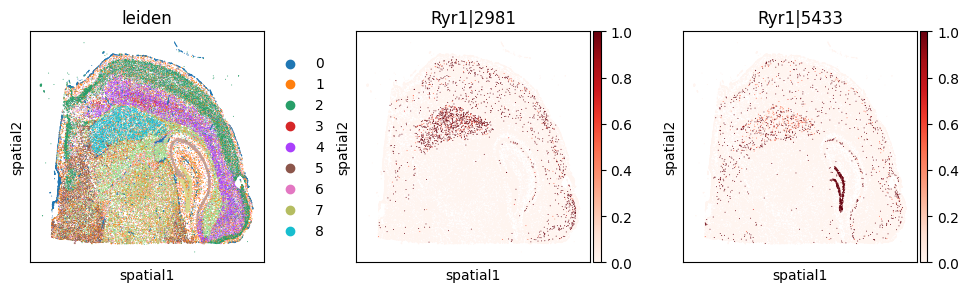

In [36]:
_cw_to_plot = adata_svp.var.query("gene_symbol == 'Ryr1'").index.tolist()
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.embedding(
        adata_svp, basis='spatial', 
        color=["leiden"] + _cw_to_plot, layer="ratios_obs", 
        cmap="Reds", vmin=0.0
    )

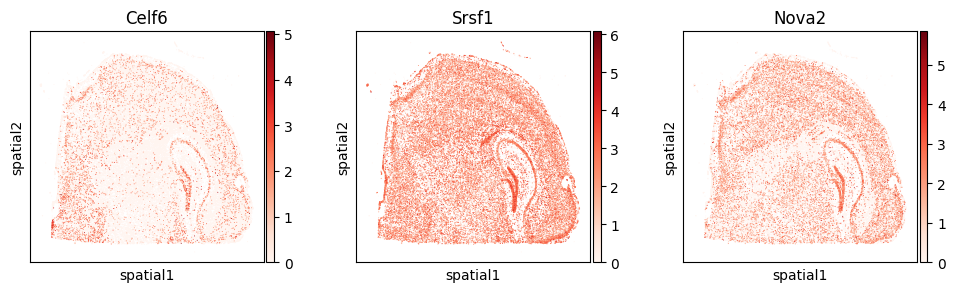

In [37]:
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.embedding(
        adata_gene, basis='spatial', 
        color=["Celf6", "Srsf1", "Nova2"], layer="log1p", 
        cmap="Reds", vmin=0.0
    )

The most significant splicing factors in our analysis include Elavl2, Elavl4, and Rbfox3.

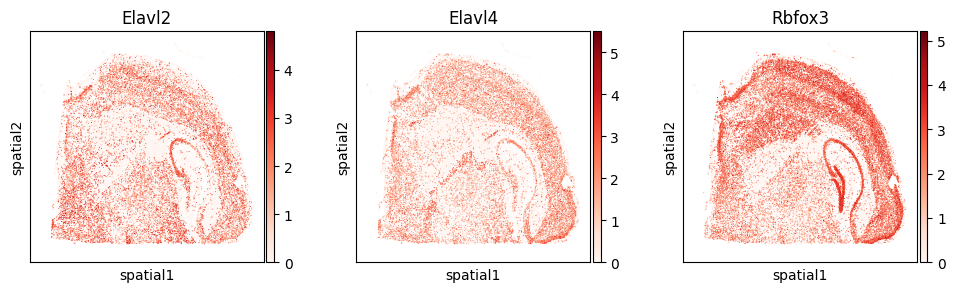

In [38]:
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.embedding(
        adata_gene, basis='spatial', 
        color=["Elavl2", "Elavl4", "Rbfox3"], layer="log1p", 
        cmap="Reds", vmin=0.0
    )

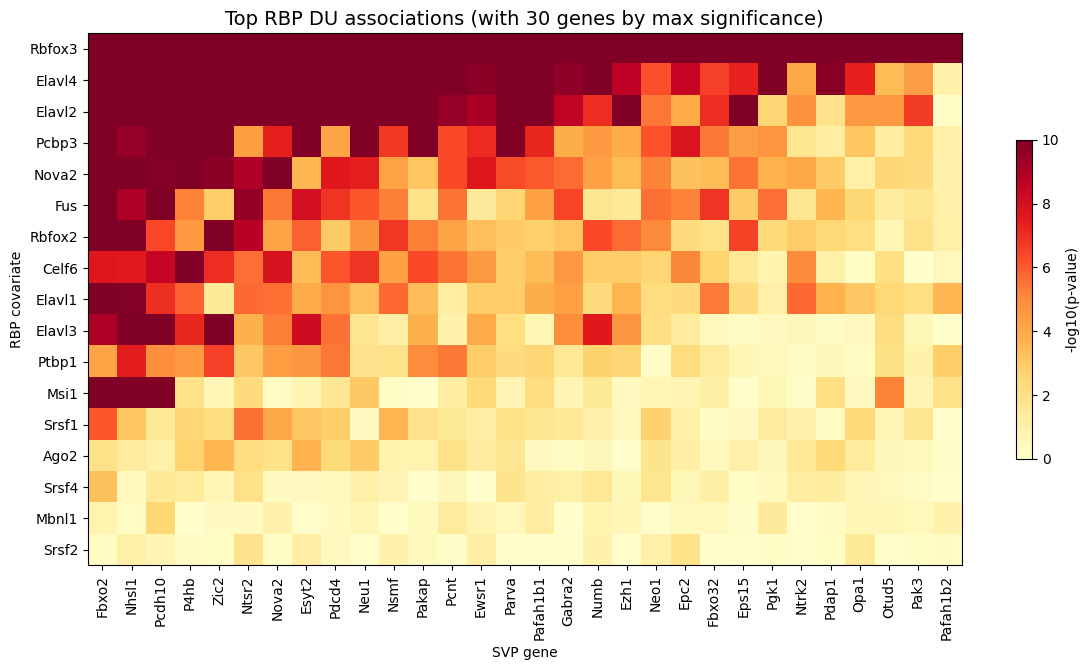

In [39]:
# Pivot to gene × RBP matrix of -log10(adjusted p-values)
pivot = du_res.pivot_table(
    index="gene", columns="covariate", values="pvalue", fill_value=1.0
)
log_p = -np.log10(pivot.clip(lower=1e-10))

# Select top 30 genes by maximum significance across all covariates
top_genes_du = log_p.max(axis=1).sort_values(ascending=False).head(30).index
log_p_top = log_p.loc[top_genes_du]

# Rank rows and columns by mean significance
log_p_transposed = log_p_top.T
rbp_order = log_p_transposed.mean(axis=1).sort_values(ascending=False).index
gene_order = log_p_transposed.mean(axis=0).sort_values(ascending=False).index
log_p_final = log_p_transposed.loc[rbp_order, gene_order]

# Plottting the heatmap
fig, ax = plt.subplots(figsize=(12, max(6, len(rbp_order) * 0.4)))
im = ax.imshow(log_p_final.values, aspect="auto", cmap="YlOrRd", vmin=0)
ax.set_xticks(range(len(log_p_final.columns)))
ax.set_xticklabels(log_p_final.columns, rotation=90, ha="center", fontsize=10) 
ax.set_yticks(range(len(log_p_final.index)))
ax.set_yticklabels(log_p_final.index, fontsize=10)

# Update axis labels
ax.set_xlabel("SVP gene")
ax.set_ylabel("RBP covariate")
ax.set_title(
    "Top RBP DU associations (with 30 genes by max significance)",
    fontsize=14
)

plt.colorbar(im, ax=ax, label="-log10(p-value)", shrink=0.6)
plt.tight_layout()
plt.show()

## Variability testing on a custom graph

Instead of using physical spatial coordinates, we can leverage the **expression-based k-NN graph** from `sc.pp.neighbors()` to detect codeword usage variability across the cell population. This approach identifies genes whose isoform usage varies across "transcriptomic neighborhoods" and continuous cell states. Conceptually, it is similar to the Moran's I-based [Hotspot analysis](https://www.sciencedirect.com/science/article/pii/S2405471221001149?via%3Dihub) for gene variability.

In [40]:
%%time
# adata_codeword.obsp['expr_knn'] = adata_gene[adata_codeword.obs_names].obsp['connectivities'].copy()

model_expr_sv = SplisosmNP(
    rho=0.99,
    standardize_cov=False, # faster
)
model_expr_sv.setup_data(
    adata=adata_codeword,
    adj_key='expr_knn',  # use expression graph instead of spatial coordinates
    layer='counts',
    group_iso_by=group_iso_by,
    gene_names=gene_name_col,
    min_counts=min_counts,
    min_bin_pct=min_bin_pct,
    filter_single_iso_genes=True,
    min_component_size=4, # same filtering but now based on expression graph connectivity
)
model_expr_sv

CPU times: user 1.12 s, sys: 700 ms, total: 1.82 s
Wall time: 2.08 s


=== SplisosmNP
- Number of genes: 3059
- Number of spots: 63173
- Number of covariates: 0
- Average isoforms per gene: 2.1
=== Model configurations
- Spatial kernel source: adj_key='expr_knn'
- k_neighbors: N/A, rho: 0.99
- Standardize spatial covariance: False
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

In [41]:
%%time
model_expr_sv.test_spatial_variability(
    method='hsic-ir',
    null_method='liu',
    print_progress=True,
)
sv_expr = model_expr_sv.get_formatted_test_results('sv', with_gene_summary=True)

SV [hsic-ir]: 100%|██████████| 203/203 [03:33<00:00,  1.05s/it]


CPU times: user 35min 22s, sys: 33.7 s, total: 35min 56s
Wall time: 6min 2s


In [42]:
sv_expr_sig = sv_expr.query('pvalue_adj < 0.01')
print(f"Expression-SVP genes (FDR < 1%): {len(sv_expr_sig)} / {len(sv_expr)}")
sv_expr.sort_values('pvalue').head(5)

Expression-SVP genes (FDR < 1%): 2549 / 3059


,gene,statistic,pvalue,pvalue_adj,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
2491,Nrcam,0.000004,0.0,0.0,2,1.913500,0.416634,0.810694,1.299188,0.647577
1236,Hpcal4,0.000005,0.0,0.0,3,2.706028,0.487629,1.602425,2.900425,0.478741
656,Mprip,0.000007,0.0,0.0,3,2.999280,0.668355,1.607506,1.783233,0.340469
2028,Baiap2,0.000007,0.0,0.0,3,2.679886,0.425102,1.220347,2.227918,0.492224
1832,Apc2,0.000003,0.0,0.0,2,1.574458,0.403638,0.671141,1.034636,0.831242


### Compare expression-SVP genes with spatial-SVP genes

We can compare the expression-SVP gene set with the spatial-SVP genes identified earlier. 

In [43]:
expr_svp_genes = set(sv_expr.query('pvalue_adj < 0.01')['gene'])
spatial_svp_genes = set(sv_liu.query('pvalue_adj < 0.01')['gene'])

print(f"Spatial SVP genes (physical coords):  {len(spatial_svp_genes)}")
print(f"Expression SVP genes (expr k-NN):     {len(expr_svp_genes)}")
print(f"Spatial SVP ∩ Expression SVP:          {len(spatial_svp_genes & expr_svp_genes)}")


Spatial SVP genes (physical coords):  782
Expression SVP genes (expr k-NN):     2549
Spatial SVP ∩ Expression SVP:          773


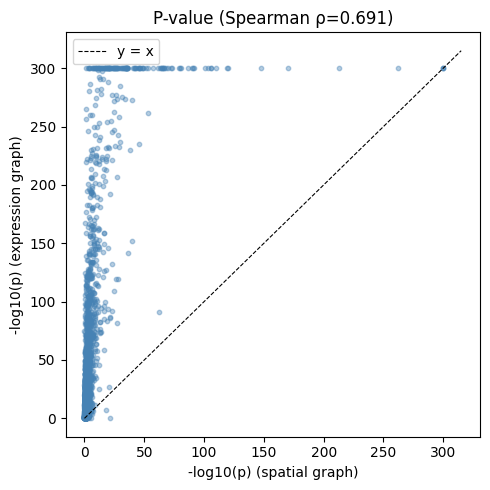

In [44]:
merged = (
    sv_liu[["gene", "statistic", "pvalue"]].rename(columns={
        "statistic": "stat_sp",
        "pvalue": "pvalue_sp"
    }).merge(
        sv_expr[["gene", "statistic", "pvalue"]].rename(columns={
            "statistic": "stat_expr", 
            "pvalue": "pvalue_expr"
        }),
        on="gene",
    )
)
rho_stat, _ = spearmanr(merged["stat_sp"], merged["stat_expr"])
rho_pval, _ = spearmanr(
    -np.log10(merged["pvalue_sp"].astype(float).clip(lower=1e-300)), 
    -np.log10(merged["pvalue_expr"].astype(float).clip(lower=1e-300))
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    -np.log10(merged["pvalue_sp"].astype(float).clip(lower=1e-300)),
    -np.log10(merged["pvalue_expr"].astype(float).clip(lower=1e-300)),
    alpha=0.4, s=10, c="steelblue", rasterized=True,
)
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="y = x")
ax.set_xlabel("-log10(p) (spatial graph)")
ax.set_ylabel("-log10(p) (expression graph)")
ax.set_title(f"P-value (Spearman ρ={rho_pval:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

Most spatially variably processed genes also show variability across the expression-based cell embedding space, with few exceptions:

In [45]:
merged.query('gene in @spatial_svp_genes').sort_values('pvalue_expr', ascending=False).head(5)

,gene,stat_sp,pvalue_sp,stat_expr,pvalue_expr
65,Spink8,1.572542e-07,5.571120e-22,1.492586e-07,0.823328
2645,Grm8,1.121168e-06,1.679057e-04,1.193935e-06,0.301492
1383,Pou3f2,8.047140e-07,8.205374e-06,8.358409e-07,0.260044
2667,Cd83,4.825617e-07,1.554153e-03,5.138478e-07,0.156517
2909,Kcna4,1.248076e-06,4.614863e-04,1.334119e-06,0.023938


Codeword usage for gene=Spink8 (SVP by spatial graph, not by expression graph)


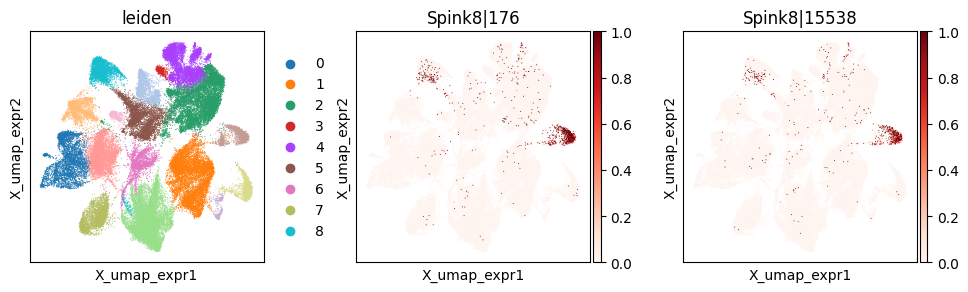

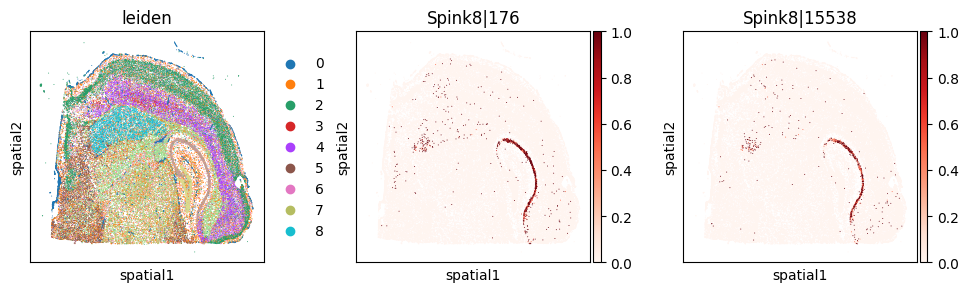

In [46]:
_gene = 'Spink8'
print(f"Codeword usage for gene={_gene} (SVP by spatial graph, not by expression graph)")

_cw_to_plot = adata_svp.var_names[adata_svp.var["gene_symbol"] == _gene].tolist()
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.embedding(
        adata_svp, basis='X_umap_expr', 
        color=["leiden"] + _cw_to_plot, layer="ratios_obs", 
        cmap="Reds", vmin=0.0
    )
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.embedding(
        adata_svp, basis='spatial', 
        color=["leiden"] + _cw_to_plot, layer="ratios_obs", 
        cmap="Reds", vmin=0.0
    )

In [47]:
merged.query('gene not in @spatial_svp_genes').sort_values('pvalue_expr').head(5)

,gene,stat_sp,pvalue_sp,stat_expr,pvalue_expr
1384,Mafb,4.629191e-07,0.113905,8.195273e-07,1.654010e-313
332,Bbs9,1.166178e-06,0.095297,1.968894e-06,5.002680e-266
818,Myo7a,5.444417e-07,0.074102,9.030015e-07,8.145254e-257
602,Hspa5,2.931829e-06,0.014084,4.644539e-06,1.443856e-222
2133,Hpgds,1.984134e-07,0.129135,3.214561e-07,3.237483e-220


Codeword usage for gene=Mafb (SVP by expression graph, not by spatial graph)


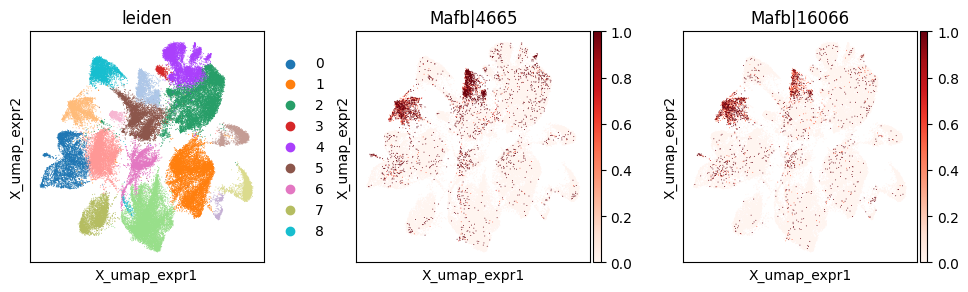

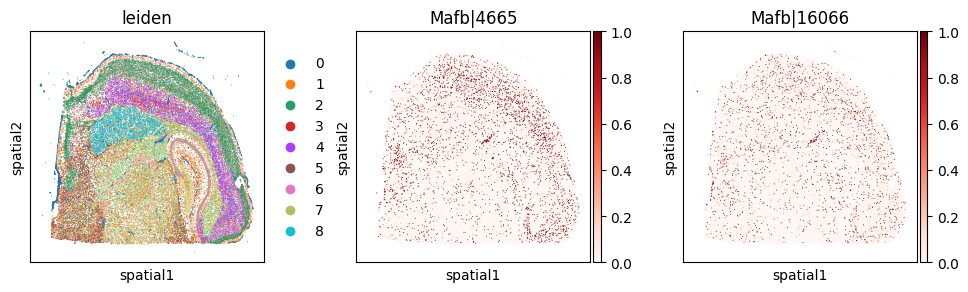

In [48]:
_gene = 'Mafb'
print(f"Codeword usage for gene={_gene} (SVP by expression graph, not by spatial graph)")

_cw_to_plot = adata_codeword.var_names[adata_codeword.var["gene_symbol"] == _gene].tolist()
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.embedding(
        adata_codeword, basis='X_umap_expr', 
        color=["leiden"] + _cw_to_plot, layer="ratios_obs", 
        cmap="Reds", vmin=0.0
    )
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.embedding(
        adata_codeword, basis='spatial', 
        color=["leiden"] + _cw_to_plot, layer="ratios_obs", 
        cmap="Reds", vmin=0.0
    )

## Summary

- `SplisosmNP`'s SV tests can detect expression and codeword usage variability across both physical space and latent expression space.
- The GP-detrended DU test (`hsic-gp`) controls false positives from spatial autocorrelation more rigorously than the unconditional test (`hsic` and T-tests).

## For reproducibility

In [49]:
import sys
from datetime import date
import splisosm

print('Last updated:', date.today())
print('Python:', sys.version.split()[0])
print('splisosm:', getattr(splisosm, '__version__', 'unknown'))

Last updated: 2026-05-03
Python: 3.12.13
splisosm: 1.2.0rc1
